# ¿Que hace exitoso un lineup? Análisis de la composición de carteles en festivales de música y su influencia en la intención de compra:

* **Asignatura:** INFB6094 - METODOLOGIA DE INVESTIGACION EN CIENCIA DE DATOS
* **Carrera:** INGENIERÍA CIVIL EN CIENCIA DE DATOS
* **Institución:** Universidad Tecnológica Metropolitana (UTEM)

---
* **Integrantes:** Christian Pérez Flores
* **Sección:** 491
* **Profesora:** Ana Moya Beltrán

In [1]:
pip install pandas bibtexparser rapidfuzz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.3 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=0e2fa04e5115ebce49eadf5482e98bf0d99574df8376fcd8f9450e00e5528049
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser


In [2]:
import pandas as pd
import bibtexparser
import re
from rapidfuzz import fuzz

In [3]:
# -----------------------
# 1. CARGAR ARCHIVOS
# -----------------------

def cargar_bib(path, fuente):
    with open(path, encoding="utf-8") as bibtex_file:
        bib_database = bibtexparser.load(bibtex_file)

    df = pd.DataFrame(bib_database.entries)
    df["source"] = fuente
    return df

scholar = cargar_bib("Scholar.bib", "Scholar")
sciencedirect = cargar_bib("ScienceDirect.bib", "ScienceDirect")
wos = cargar_bib("wos.bib", "WoS")
scopus = cargar_bib("scopus.bib", "Scopus")

In [4]:
# -----------------------
# 2. UNIR TODO
# -----------------------

df = pd.concat([scholar, sciencedirect, wos, scopus], ignore_index=True)

print("Total inicial:", len(df))
print("\nConteo por fuente (antes):")
print(df["source"].value_counts())


Total inicial: 358

Conteo por fuente (antes):
source
Scopus           144
ScienceDirect     95
WoS               61
Scholar           58
Name: count, dtype: int64


In [5]:
# -----------------------
# 3. LIMPIEZA DE TEXTO
# -----------------------

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r'\{|\}', '', texto)
    texto = re.sub(r'\W+', ' ', texto)  # elimina símbolos
    texto = re.sub(r'\s+', ' ', texto)  # espacios múltiples
    texto = texto.strip()
    return texto

df["title_clean"] = df["title"].apply(limpiar_texto)

# Normalizar DOI
if "doi" in df.columns:
    df["doi"] = df["doi"].astype(str).str.lower().str.strip()
else:
    df["doi"] = ""

In [6]:
# -----------------------
# 4. ELIMINAR DUPLICADOS (ETAPA 1)
# -----------------------

# 4.1 DOI
df_no_dup = df.copy()
df_no_dup = df_no_dup.drop_duplicates(subset="doi", keep="first")

# 4.2 Título exacto
df_no_dup = df_no_dup.drop_duplicates(subset="title_clean", keep="first")

print("\nDespués de deduplicación exacta:", len(df_no_dup))


Después de deduplicación exacta: 315


In [7]:
# -----------------------
# 5. DEDUPLICACIÓN FUZZY (ETAPA 2)
# -----------------------

def son_similares(t1, t2, threshold=92):
    return fuzz.ratio(t1, t2) >= threshold

titulos = df_no_dup["title_clean"].tolist()
indices_a_eliminar = set()

for i in range(len(titulos)):
    if i in indices_a_eliminar:
        continue
    for j in range(i + 1, len(titulos)):
        if j in indices_a_eliminar:
            continue

        # Solo comparar si longitud similar (optimización)
        if abs(len(titulos[i]) - len(titulos[j])) > 20:
            continue

        if son_similares(titulos[i], titulos[j]):
            indices_a_eliminar.add(j)

df_final = df_no_dup.drop(df_no_dup.index[list(indices_a_eliminar)])


In [8]:
# -----------------------
# 6. RESULTADOS
# -----------------------

print("\nRESULTADOS FINALES")
print("-------------------")
print("Total después de limpieza:", len(df_final))
print("Duplicados eliminados totales:", len(df) - len(df_final))
print("Duplicados eliminados por fuzzy:", len(df_no_dup) - len(df_final))

print("\nConteo por fuente (final):")
print(df_final["source"].value_counts())



RESULTADOS FINALES
-------------------
Total después de limpieza: 315
Duplicados eliminados totales: 43
Duplicados eliminados por fuzzy: 0

Conteo por fuente (final):
source
Scopus           129
ScienceDirect     90
WoS               51
Scholar           45
Name: count, dtype: int64


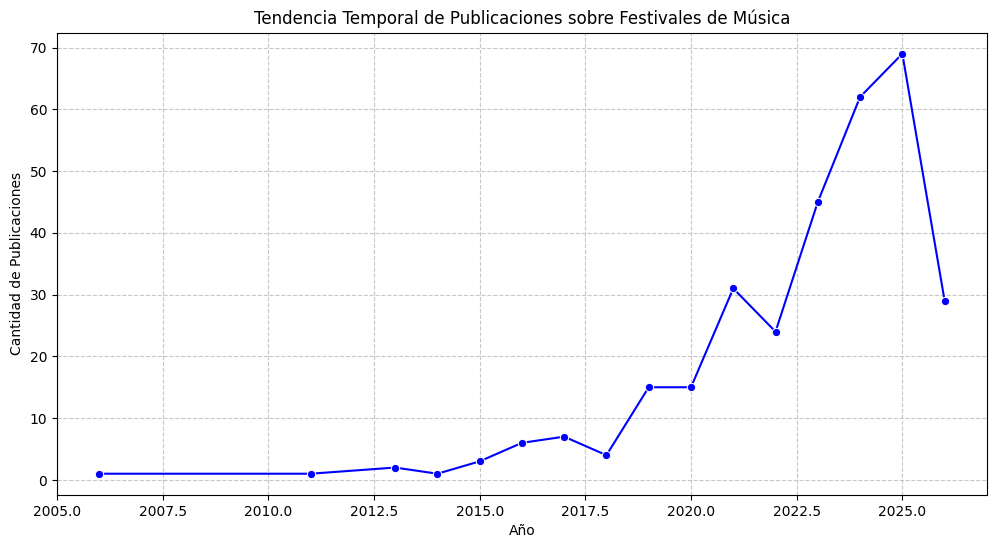

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que 'year' sea numérico
df_final['year'] = pd.to_numeric(df_final['year'], errors='coerce')

# Agrupar por año y contar publicaciones
tendencia = df_final.groupby('year').size().reset_index(name='conteo')

# Crear el gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(data=tendencia, x='year', y='conteo', marker='o', color='b')

plt.title('Tendencia Temporal de Publicaciones sobre Festivales de Música')
plt.xlabel('Año')
plt.ylabel('Cantidad de Publicaciones')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
# -----------------------
# 7. PREPARAR DATASET FINAL
# -----------------------

# Seleccionar columnas importantes (si existen)
columnas = ["title", "abstract", "year", "author", "journal", "doi", "source"]

# Filtrar solo columnas que realmente están
columnas_existentes = [col for col in columnas if col in df_final.columns]

df_export = df_final[columnas_existentes].copy()

# Rellenar NaN en abstract
if "abstract" in df_export.columns:
    df_export["abstract"] = df_export["abstract"].fillna("")

# -----------------------
# 8. EXPORTAR
# -----------------------

df_export.to_excel("base_prisma.xlsx", index=False)

print("\nArchivo exportado: base_prisma.xlsx")
print("Columnas incluidas:", columnas_existentes)


Archivo exportado: base_prisma.xlsx
Columnas incluidas: ['title', 'abstract', 'year', 'author', 'journal', 'doi', 'source']


In [10]:
# -----------------------
# 9. PRE-FILTRO AUTOMÁTICO
# -----------------------

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r'\W+', ' ', texto)
    return texto

# Unir título + abstract
df_export["text"] = (
    df_export["title"].fillna("") + " " +
    df_export["abstract"].fillna("")
).apply(limpiar_texto)

# -----------------------
# KEYWORDS
# -----------------------

keywords_inclusion = [
    "music festival",
    "festival",
    "live music",
    "concert",
    "consumer behavior",
    "purchase intention",
    "ticket sales",
    "audience",
]

keywords_exclusion = [
    "medical",
    "disease",
    "biology",
    "chemistry",
    "patient",
    "clinical",
    "drug",
]

# -----------------------
# FUNCIÓN DE SCORE
# -----------------------

def calcular_score(texto):
    score = 0

    for word in keywords_inclusion:
        if word in texto:
            score += 2

    for word in keywords_exclusion:
        if word in texto:
            score -= 3

    return score

df_export["score"] = df_export["text"].apply(calcular_score)

# -----------------------
# CLASIFICACIÓN
# -----------------------

df_export["relevante"] = df_export["score"] >= 2

# -----------------------
# RESULTADOS
# -----------------------

print("\nConteo relevancia:")
print(df_export["relevante"].value_counts())

# -----------------------
# FILTRAR
# -----------------------

df_filtrado = df_export[df_export["relevante"] == True]

print("\nTotal después de filtro automático:", len(df_filtrado))

# -----------------------
# EXPORTAR
# -----------------------

df_filtrado.to_excel("base_filtrada.xlsx", index=False)

print("\nArchivo exportado: base_filtrada.xlsx")


Conteo relevancia:
relevante
False    237
True      78
Name: count, dtype: int64

Total después de filtro automático: 78

Archivo exportado: base_filtrada.xlsx
